Dataset loaded successfully!

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5 

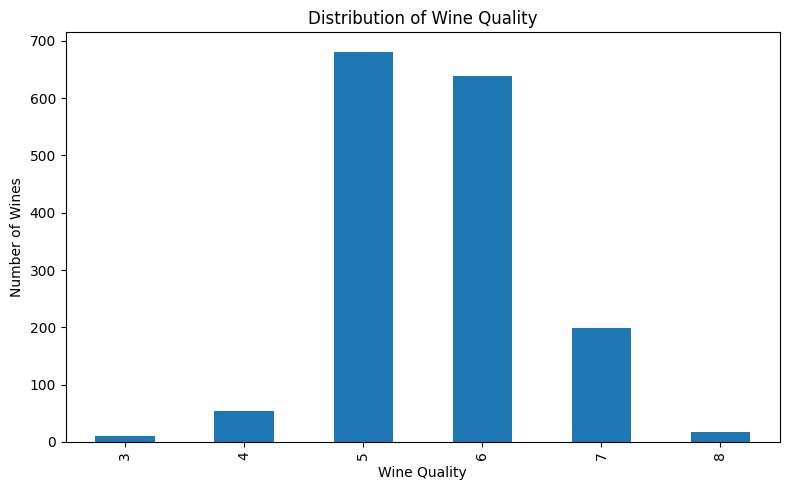


Input Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target:
quality

Training Data Size: (1279, 11)
Testing Data Size: (320, 11)

Random Forest model trained successfully!

MODEL PERFORMANCE
Random Forest Accuracy: 0.678125
Accuracy Percentage: 67.8125 %

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.65      0.70      0.67       128
           7       0.71      0.55      0.62        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.65      0.68      0.66       320


Confusion Matrix:
[[  0   1   1   0   0

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


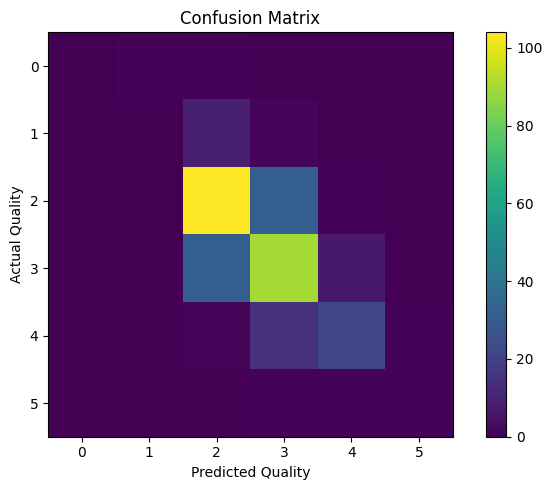


RANDOM FOREST FEATURE IMPORTANCE
             Feature  Importance
             alcohol    0.152106
           sulphates    0.112057
    volatile acidity    0.103678
total sulfur dioxide    0.101487
             density    0.088812
           chlorides    0.079941
                  pH    0.079460
       fixed acidity    0.076209
      residual sugar    0.073386
         citric acid    0.068562
 free sulfur dioxide    0.064303


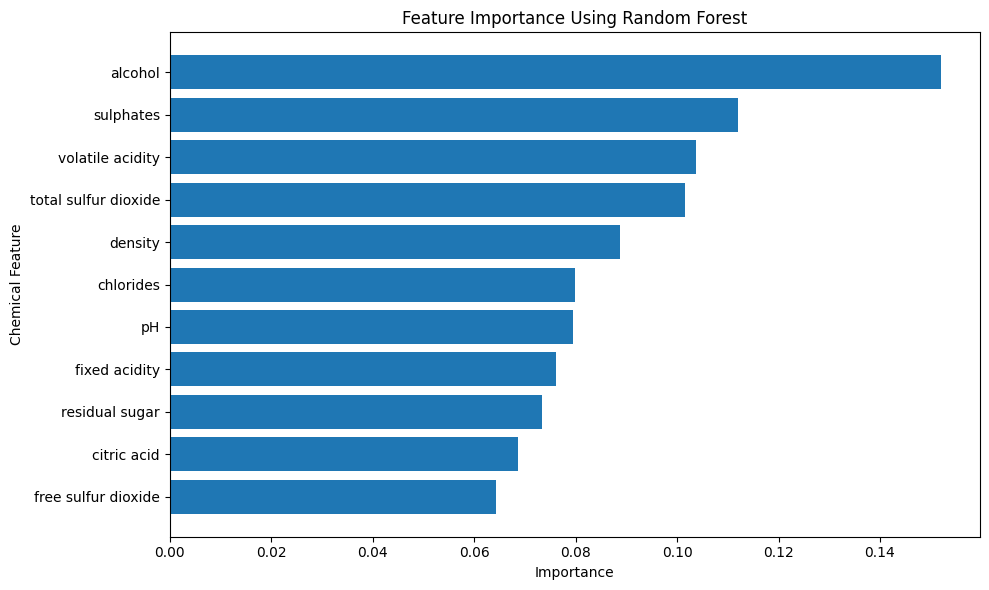


PERMUTATION FEATURE IMPORTANCE
             Feature  Importance
             alcohol    0.130625
           sulphates    0.065937
    volatile acidity    0.048125
total sulfur dioxide    0.021562
 free sulfur dioxide    0.011875
           chlorides    0.010312
         citric acid    0.009687
                  pH    0.008750
             density    0.008437
      residual sugar    0.006250
       fixed acidity    0.001250


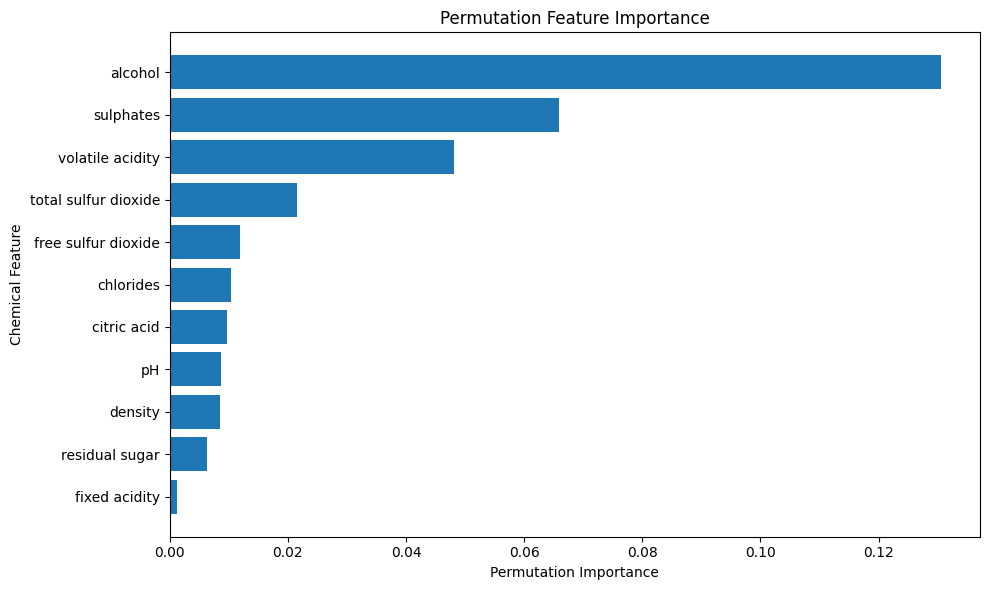


PROJECT EXECUTION COMPLETED

Files created:
1. wine_quality_distribution.png
2. confusion_matrix.png
3. wine_feature_importance.png
4. permutation_feature_importance.png
5. Random_Forest_Feature_Importance.xlsx
6. Permutation_Feature_Importance.xlsx

Main Algorithm: Random Forest
Main Project Task: Feature Importance Analysis


In [ ]:
# ============================================================
# FEATURE IMPORTANCE ANALYSIS FOR WINE QUALITY USING RANDOM FOREST
# ============================================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance


# ============================================================
# 2. Load Dataset
# ============================================================

# Change the filename if your Excel file has a different name
df = pd.read_excel("Red_Wine_Quality_Dataset.xlsx")

print("Dataset loaded successfully!")


# ============================================================
# 3. Display Dataset
# ============================================================

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


# ============================================================
# 4. Check Missing Values
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 5. Handle Missing Values
# ============================================================

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])


print("\nMissing values after cleaning:")
print(df.isnull().sum())


# ============================================================
# 6. Basic Statistical Analysis
# ============================================================

print("\nStatistical Summary:")
print(df.describe())


# ============================================================
# 7. Wine Quality Distribution
# ============================================================

print("\nWine Quality Distribution:")
print(df["quality"].value_counts().sort_index())


# ============================================================
# 8. EDA - Wine Quality Distribution Graph
# ============================================================

plt.figure(figsize=(8, 5))

df["quality"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")
plt.title("Distribution of Wine Quality")

plt.tight_layout()
plt.savefig("wine_quality_distribution.png", dpi=150)
plt.show()


# ============================================================
# 9. Separate Input Features and Target
# ============================================================

X = df.drop(columns=["quality"])
y = df["quality"]

print("\nInput Features:")
print(X.columns.tolist())

print("\nTarget:")
print("quality")


# ============================================================
# 10. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)


# ============================================================
# 11. Create Random Forest Model
# ============================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# ============================================================
# 12. Train the Model
# ============================================================

model.fit(X_train, y_train)

print("\nRandom Forest model trained successfully!")


# ============================================================
# 13. Predict Wine Quality
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 14. Model Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print("Random Forest Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


# ============================================================
# 15. Classification Report
# ============================================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ============================================================
# 16. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")
plt.title("Confusion Matrix")

plt.colorbar()

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


# ============================================================
# 17. Random Forest Feature Importance
# ============================================================

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})


# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print("\n===================================")
print("RANDOM FOREST FEATURE IMPORTANCE")
print("===================================")

print(feature_importance.to_string(index=False))


# ============================================================
# 18. Feature Importance Graph
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Chemical Feature")
plt.title("Feature Importance Using Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("wine_feature_importance.png", dpi=150)
plt.show()


# ============================================================
# 19. Permutation Importance
# ============================================================

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)


permutation_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})


# Sort from highest to lowest
permutation_importance_df = permutation_importance_df.sort_values(
    by="Importance",
    ascending=False
)


print("\n===================================")
print("PERMUTATION FEATURE IMPORTANCE")
print("===================================")

print(permutation_importance_df.to_string(index=False))


# ============================================================
# 20. Permutation Importance Graph
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    permutation_importance_df["Feature"],
    permutation_importance_df["Importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Chemical Feature")
plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("permutation_feature_importance.png", dpi=150)
plt.show()


# ============================================================
# 21. Save Results to Excel
# ============================================================

feature_importance.to_excel(
    "Random_Forest_Feature_Importance.xlsx",
    index=False
)

permutation_importance_df.to_excel(
    "Permutation_Feature_Importance.xlsx",
    index=False
)


# ============================================================
# 22. Final Message
# ============================================================

print("\n===================================")
print("PROJECT EXECUTION COMPLETED")
print("===================================")

print("\nFiles created:")
print("1. wine_quality_distribution.png")
print("2. confusion_matrix.png")
print("3. wine_feature_importance.png")
print("4. permutation_feature_importance.png")
print("5. Random_Forest_Feature_Importance.xlsx")
print("6. Permutation_Feature_Importance.xlsx")

print("\nMain Algorithm: Random Forest")
print("Main Project Task: Feature Importance Analysis")